In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import entr
import itertools

from ligand_coding_model import *
from receptor_information import *

# --- 1. Define General Parameters ---
Nr = 3  # Number of receptors (e.g., r0, r1, r2)

# Binning parameters
# binning parameters influence the indexing of the response.
# this is why, we define them on top
Na,Nc = 10,10
# concentration bins
c_min = 0.01
c_max = 10.0
c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
# activity bins
a_edges = np.linspace(0, 1, Na + 1)
a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
a_centers[0] = 0.
a_centers[-1] = 1.

In [70]:
from scipy.special import entr
def compute_mi(discrete_A,Na):

    L, Nr, Nc = discrete_A.shape
    
    N_total = L * Nc
    
    events_matrix = discrete_A.transpose(0, 2, 1).reshape(-1, Nr)
    
    _, counts = np.unique(events_matrix, axis=0, return_counts=True)
    
    # M_A contains the counts of only the states that actually occurred.
    M_A = counts
    
    # 4. Compute Probabilities P(A)
    P_A = M_A / N_total
    
    MI = np.sum(entr(P_A))
    
    return MI
def compute_PA(discrete_A, Na):
    """
    Computes the histogram of activity vectors and the Mutual Information.
    
    Formula: MI = log(N_total) - Sum( (M_A / N_total) * log(M_A) )
    
    Args:
        discrete_A: Array of shape (L, Nr, Nc).
        Na: Number of activity bins.
    """
    L, Nr, Nc = discrete_A.shape
    
    # 1. Define N_total (Total number of events 3L in toy model, L*Nc here)
    N_total = L * Nc
    
    # 2. Reshape the matrix to list of events (N_total, Nr)
    # Transpose to (L, Nc, Nr) so the receptor vector is the last dimension
    # Reshape flattens L and Nc into one dimension
    events_matrix = discrete_A.transpose(0, 2, 1).reshape(-1, Nr)
    
    # 3. Convert each event vector to a unique index
    indices = response_to_index_vectorized(events_matrix, Na)
    
    # 4. Compute Multiplicity M_A (Histogram)
    # The maximum possible index is Na^Nr
    max_state_index = Na ** Nr
    
    # np.bincount is a fast histogram for integers
    # M_all[idx] = count of how many times state 'idx' appeared
    M_all = np.bincount(indices, minlength=max_state_index)
    
    # 5. Filter to keep only observed states (where M_A > 0)
    observed_mask = M_all > 0
    
    # The Multiplicities (M_A) of observed states
    M_A = M_all[observed_mask]
    
    # The indices of observed states
    observed_indices = np.where(observed_mask)[0]
    
    # 6. Compute Probabilities P(A)
    P_A = M_all / N_total
    
    return P_A
# --- Helper to Compute Marginal P(a) ---
def compute_marginal_P(discrete_A, Na):
    """
    Computes the marginal probability of each activity bin (0 to Na-1)
    observed across all ligands and receptors in the matrix.
    
    Returns:
        prob_vector: Array of shape (Na,) summing to 1.
    """
    # Flatten to treat all observations equally
    flat_A = discrete_A.ravel()
    # Count occurrences of each bin
    counts = np.bincount(flat_A, minlength=Na)
    # Normalize
    return counts / flat_A.size

In [71]:
Kcs_2,       Kos_2,       eps_2       = generate_Ks(L=L_curr, n_types=2, n_hetero_sample=0)
A_2       = generate_activity_matrix(eps_2,       Kcs_2,       Kos_2,       c_centers, a_edges)
Pa = compute_marginal_P(A_2,Na)
print(Pa.shape)
print(Pa)

(10,)
[0.214  0.0865 0.061  0.0545 0.0425 0.05   0.0385 0.0545 0.057  0.3415]


In [14]:
Pa.shape

(60,)

In [80]:
Nsamples = 1000
L_values = np.array([2, 5, 10, 25, 50, 100, 150, 200, 500,1000])
L_values = np.array([2, 5, 10, 25, 50, 100,1000])

# Storage
av_MIL = np.zeros((len(L_values)), dtype=float)
av_PA = np.zeros((len(L_values),Na ** Nr), dtype=float)
av_Pa = np.zeros((len(L_values),Na), dtype=float)

for l_idx, L_curr in enumerate(L_values):
    print(f"Processing L = {L_curr}...")
    
    MI_3hetero, MI_3homo, MI_2 = [], [], []
    PA_3homo = []
    Pa_3homo = []
    # Temporary accumulators for P(a)
    sum_Pa_3hetero = np.zeros(Na)
    sum_Pa_3homo   = np.zeros(Na)
    sum_Pa_2       = np.zeros(Na)
    
    for k in range(Nsamples):
        # 1. Generate Parameters
        # Note: using 'n_hetero_sample' argument from previous generalized function
        #Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=2, n_hetero_sample='all')
        Kcs_3homo,   Kos_3homo,   eps_3homo   = generate_Ks(L=L_curr, n_types=3, n_hetero_sample=0)
        #Kcs_2,       Kos_2,       eps_2       = generate_Ks(L=L_curr, n_types=2, n_hetero_sample=0)
        
        # 2. Generate Activity Matrices
        #A_3hetero = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges)
        A_3homo   = generate_activity_matrix(eps_3homo,   Kcs_3homo,   Kos_3homo,   c_centers, a_edges)
        #A_2       = generate_activity_matrix(eps_2,       Kcs_2,       Kos_2,       c_centers, a_edges)
        
        #MI_3hetero.append(compute_mi(A_3hetero, Na))
        MI_3homo.append(compute_mi(A_3homo, Na))
        #MI_2.append(compute_mi(A_2, Na))

        #Pa_3hetero.append(compute_PA(A_3hetero,Na))
        PA_3homo.append(compute_PA(A_3homo,Na))
        #Pa_2.append(compute_PA(A_2,Na))

        Pa_3homo.append(compute_marginal_P(A_3homo,Na))

    # --- Store Averages for this L ---    
    # Average MI
    av_MIL[l_idx] = np.mean(MI_3homo)#[np.mean(MI_2), np.mean(MI_3hetero), np.mean(MI_3homo)]
    av_PA[l_idx] = np.mean(PA_3homo,axis=0)
    av_Pa[l_idx] = np.mean(Pa_3homo,axis=0)

Processing L = 2...
Processing L = 5...
Processing L = 10...
Processing L = 25...
Processing L = 50...
Processing L = 100...
Processing L = 1000...


/tmp/ipykernel_29811/1839214485.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


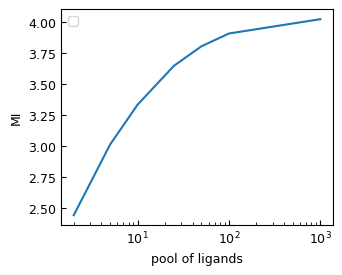

In [81]:
names = ['homo2','homo2, hetero5','homo3']
colors = ['b','g','r']
plt.plot(L_values,av_MIL)
plt.xlabel('pool of ligands')
plt.ylabel('MI')
plt.xscale('log')
plt.legend()

Text(0.5, 0, 'index of a specific activation array')

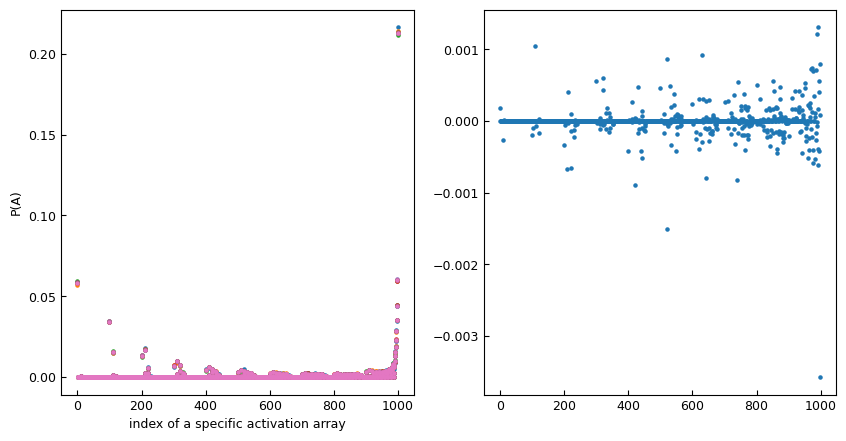

In [84]:
fig,ax = plt.subplots(ncols=2,figsize=(10,5))
for i in range(av_PA.shape[0]):
    ax[0].scatter(np.arange(0,av_PA.shape[1],1),av_PA[i],s=5.)
ax[1].scatter(np.arange(0,av_PA.shape[1],1),av_PA[-1]-av_PA[0],s=5.)
ax[0].set_ylabel('P(A)')
ax[0].set_xlabel('index of a specific activation array')
#ax[1].set_yscale('log')

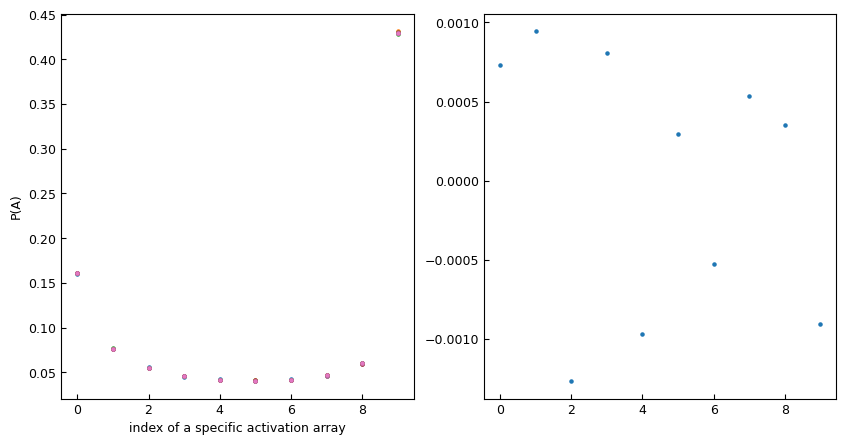

In [85]:
fig,ax = plt.subplots(ncols=2,figsize=(10,5))
for i in range(av_Pa.shape[0]):
    ax[0].scatter(np.arange(0,av_Pa.shape[1],1),av_Pa[i],s=5.)
ax[0].set_ylabel('P(A)')
ax[0].set_xlabel('index of a specific activation array')

ax[1].scatter(np.arange(0,av_Pa.shape[1],1),av_Pa[-1] - av_Pa[0],s=5.)
#ax.set_yscale('log')